# ML 앙상블 최적 조합 탐색 실험

## 노트북 목적
이 노트북은 01_experiment에서 확인된 개별 ML 모델들을 **앙상블(Ensemble)** 방식으로 조합하여 최적의 분류 성능을 달성하는 조합을 탐색합니다.

### 핵심 개념
- **앙상블(Ensemble)**: 여러 모델의 예측을 결합하여 단일 모델보다 더 나은 성능을 얻는 방법
- **Condorcet 배심원 정리**: 각 배심원(모델)이 50% 이상의 정확도를 가지고, 오류가 서로 독립적이면, 배심원 수가 많을수록 다수결의 정확도가 높아진다는 원리
- **Voting(투표)**: 여러 모델의 예측을 다수결(Hard) 또는 확률 평균(Soft)으로 결합
- **Stacking(스태킹)**: 기본 모델들의 예측을 새로운 메타 학습기의 입력으로 사용하여 최종 예측

### 실험 설계
| 요소 | 내용 |
|------|------|
| 후보 조합 | Condorcet 시뮬레이션 기반 5개 조합 (C1~C5) |
| 앙상블 전략 | Hard Voting, Soft Voting, Stacking |
| 벡터화 | V1_Word (최적 벡터화) 고정 |
| 총 실험 | 3 seeds x 5 조합 x 3 전략 = **45개** |

# ML 앙상블 최적 조합 탐색 (Condorcet 배심원 정리 기반)

## 실험 목적
1. **최적 앙상블 구성 탐색**: Condorcet 배심원 정리의 두 조건(개별 역량 + 오류 독립성)에 기반하여 선정한 후보 조합들을 체계적으로 비교
2. **앙상블 전략 비교**: 각 조합에 대해 Hard Voting, Soft Voting, Stacking 3가지 방법 평가
3. **학생별 예측 기록**: 각 학생 응답에 대해 개별 모델이 어떤 label을 부여했는지 기록

## 후보 앙상블 조합
| 조합 | 구성 | 선정 근거 |
|------|------|----------|
| C1 (최적 5개) | SVM-L + CNB + DT + GB + XGB | Condorcet 시뮬레이션 1위, 최고 다양성 |
| C2 (차선 5개) | LR + SVM-L + DT + GB + XGB | Condorcet 시뮬레이션 2위, 선형 앵커 2개 |
| C3 (최적 3개) | LR + SVM-RBF + XGB | 3-모델 시뮬레이션 1위, 최소 구성 |
| C4 (기존 4개) | LR + SVM-L + CNB + RF | 기존 05_final_experiment 조합 (비교 기준) |
| C5 (기존 5개) | LR + SVM-RBF + CNB + RF + LGBM | 기존 06_final_ensemble 조합 (비교 기준) |

## 워크플로우
```
각 (seed, 조합) 에 대해:
1. V1_Word 벡터화 수행
2. 개별 모델 학습 → 개별 예측 기록
3. Hard Voting / Soft Voting / Stacking 앙상블 구성
4. Stratified 10-Fold CV → CV 성능
5. 테스트 평가 → 성능 + 학생별 예측 저장
```

---
## 1. 환경 설정

01_experiment와 동일한 라이브러리를 사용합니다. `VotingClassifier`와 `StackingClassifier`가 앙상블 구현의 핵심입니다.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import os
import platform
from datetime import datetime
from copy import deepcopy
import json
from itertools import combinations
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# 한국어 형태소 분석기
from kiwipiepy import Kiwi

# 전처리 및 벡터화
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# 분류 알고리즘
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Cross-validation
from sklearn.model_selection import StratifiedKFold

# 평가
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# 결과 저장 디렉토리
OUTPUT_DIR = './results/optimal_ensemble'
os.makedirs(f'{OUTPUT_DIR}/summary', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/predictions', exist_ok=True)

print(f"운영체제: {platform.system()}")
print(f"실험 시작: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("라이브러리 로드 완료!")

운영체제: Darwin
실험 시작: 2026-02-11 14:29:56
라이브러리 로드 완료!


---
## 2. 데이터 로드

앙상블 실험에서도 동일한 3개 seed(42, 43, 44)의 데이터 분할을 사용하여 결과의 일관성을 보장합니다.

In [11]:
DATA_PATH = '../data/feedback_data.xlsx'
SEEDS = [42, 43, 44]

TEXT_COLUMN = 'feedback_text'
LABEL_COLUMN = 'label'
ID_COLUMN = 'id'

datasets = {}
for seed in SEEDS:
    all_df = pd.read_excel(DATA_PATH)  # data/feedback_data.xlsx (main 시트)
    train_df = all_df[all_df[f'split_seed{seed}'] == 'train'].reset_index(drop=True)
    test_df = all_df[all_df[f'split_seed{seed}'] == 'test'].reset_index(drop=True)

    datasets[seed] = {'train': train_df, 'test': test_df}
    print(f"Seed {seed}: Train={train_df.shape}, Test={test_df.shape}")

print(f"\n컬럼: {datasets[42]['train'].columns.tolist()}")

Seed 42: Train=(1664, 3), Test=(416, 3)
Seed 43: Train=(1664, 3), Test=(416, 3)
Seed 44: Train=(1664, 3), Test=(416, 3)

컬럼: ['id', 'feedback_text', 'label']


---
## 3. 형태소 처리 (Kiwi + Lemmatization)

01_experiment와 동일한 Kiwi 형태소 분석기를 사용하여 텍스트를 전처리합니다.
형태소 분석 결과는 이후 TF-IDF 벡터화의 입력으로 사용됩니다.

In [12]:
class KiwiLemmaTokenizer:
    INCLUDE_POS = {
        'NNG', 'NNP', 'NNB', 'NR',
        'VV', 'VA', 'VX',
        'MAG', 'MAJ',
    }

    def __init__(self):
        self.kiwi = Kiwi()
        print("Kiwi 형태소 분석기 초기화 완료")

    def tokenize_with_lemma(self, text):
        if pd.isna(text) or str(text).strip() == '':
            return ''
        text = str(text)
        tokens = self.kiwi.tokenize(text)
        lemmas = []
        for token in tokens:
            if token.tag in self.INCLUDE_POS:
                lemma = token.lemma if token.lemma else token.form
                lemmas.append(lemma)
        return ' '.join(lemmas)

tokenizer = KiwiLemmaTokenizer()

print("전체 데이터 토큰화 중...")
for seed in SEEDS:
    print(f"  Seed {seed}...", end=' ')
    datasets[seed]['train']['tokenized'] = datasets[seed]['train'][TEXT_COLUMN].apply(
        tokenizer.tokenize_with_lemma
    )
    datasets[seed]['test']['tokenized'] = datasets[seed]['test'][TEXT_COLUMN].apply(
        tokenizer.tokenize_with_lemma
    )
    print("완료")
print("토큰화 완료!")

Kiwi 형태소 분석기 초기화 완료
전체 데이터 토큰화 중...
  Seed 42... 

Quantization is not supported for ArchType::neon. Fall back to non-quantized model.


완료
  Seed 43... 완료
  Seed 44... 완료
토큰화 완료!


---
## 4. 벡터화 및 분류기 정의

In [13]:
def custom_tokenizer(text):
    return text.split() if text else []

def identity_preprocessor(text):
    return text

def create_vectorizer():
    """V1_Word 벡터화 객체 생성 (최적 벡터화)"""
    return TfidfVectorizer(
        tokenizer=custom_tokenizer,
        preprocessor=identity_preprocessor,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )

print("벡터화: V1_Word (Word TF-IDF, lemma, ngram 1-2)")

벡터화: V1_Word (Word TF-IDF, lemma, ngram 1-2)


01_experiment에서 가장 좋은 성능을 보인 **V1_Word 벡터화**(단어 단위 TF-IDF)만 사용합니다.

분류기는 두 종류로 구분합니다:
- **`get_single_classifier()`**: Hard Voting용 (LinearSVC 등 확률 출력 불필요)
- **`get_soft_classifier()`**: Soft Voting/Stacking용 (확률 출력이 필요하므로 LinearSVC → SVC(linear)로 대체)

In [14]:
def get_single_classifier(name, random_state=42):
    """이름으로 단일 분류기 반환"""
    classifiers = {
        'LR': LogisticRegression(
            class_weight='balanced', max_iter=1000,
            random_state=random_state, n_jobs=-1
        ),
        'SVM-L': LinearSVC(
            class_weight='balanced', max_iter=2000,
            random_state=random_state
        ),
        'SVM-RBF': SVC(
            kernel='rbf', class_weight='balanced',
            random_state=random_state, probability=True
        ),
        'CNB': ComplementNB(alpha=1.0),
        'RF': RandomForestClassifier(
            n_estimators=100, class_weight='balanced',
            random_state=random_state, n_jobs=-1
        ),
        'DT': DecisionTreeClassifier(
            class_weight='balanced',
            random_state=random_state
        ),
        'GB': GradientBoostingClassifier(
            n_estimators=100,
            random_state=random_state
        ),
        'XGB': XGBClassifier(
            n_estimators=100, use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=random_state, n_jobs=-1, verbosity=0
        ),
        'LGBM': LGBMClassifier(
            n_estimators=100, class_weight='balanced',
            random_state=random_state, n_jobs=-1, verbose=-1
        ),
    }
    return classifiers[name]


def get_soft_classifier(name, random_state=42):
    """
    Soft Voting / Stacking용 분류기 반환.
    LinearSVC는 probability 미지원 → SVC(kernel='linear')로 대체.
    """
    if name == 'SVM-L':
        return SVC(
            kernel='linear', class_weight='balanced',
            random_state=random_state, probability=True
        )
    return get_single_classifier(name, random_state)


print("분류기 정의 완료")

분류기 정의 완료


### Condorcet 시뮬레이션 기반 조합 선정
Condorcet 배심원 정리의 핵심 조건 두 가지:
1. **개별 역량**: 각 모델의 정확도가 50%를 초과해야 함
2. **오류 독립성**: 모델들이 서로 다른 유형의 오류를 범해야 함 (다양성)

이 두 조건을 기반으로 시뮬레이션한 결과에서 상위 조합들과 기존 실험 조합을 후보로 선정했습니다.

---
## 5. 앙상블 조합 정의

In [15]:
# Condorcet 분석 결과 기반 후보 조합
ENSEMBLE_COMBOS = {
    'C1_Optimal5': ['SVM-L', 'CNB', 'DT', 'GB', 'XGB'],  # Condorcet 시뮬레이션 1위, 최고 다양성
    'C2_Alt5':     ['LR', 'SVM-L', 'DT', 'GB', 'XGB'],  # Condorcet 시뮬레이션 2위
    'C3_Optimal3': ['LR', 'SVM-RBF', 'XGB'],  # 3-모델 시뮬레이션 1위, 최소 구성
    'C4_Prev4':    ['LR', 'SVM-L', 'CNB', 'RF'],  # 기존 실험 조합 (비교 기준)
    'C5_Prev5':    ['LR', 'SVM-RBF', 'CNB', 'RF', 'LGBM'],  # 기존 실험 조합 (비교 기준)
}

# 앙상블 전략
ENSEMBLE_METHODS = ['Hard Voting', 'Soft Voting', 'Stacking']

# 전체 실험 조합 수
total_experiments = len(SEEDS) * len(ENSEMBLE_COMBOS) * len(ENSEMBLE_METHODS)

print("앙상블 후보 조합:")
for name, models in ENSEMBLE_COMBOS.items():
    print(f"  {name}: {' + '.join(models)} ({len(models)}개)")
print(f"\n앙상블 전략: {ENSEMBLE_METHODS}")
print(f"Seeds: {SEEDS}")
print(f"총 실험 수: {len(SEEDS)} seeds x {len(ENSEMBLE_COMBOS)} combos x {len(ENSEMBLE_METHODS)} methods = {total_experiments}")

앙상블 후보 조합:
  C1_Optimal5: SVM-L + CNB + DT + GB + XGB (5개)
  C2_Alt5: LR + SVM-L + DT + GB + XGB (5개)
  C3_Optimal3: LR + SVM-RBF + XGB (3개)
  C4_Prev4: LR + SVM-L + CNB + RF (4개)
  C5_Prev5: LR + SVM-RBF + CNB + RF + LGBM (5개)

앙상블 전략: ['Hard Voting', 'Soft Voting', 'Stacking']
Seeds: [42, 43, 44]
총 실험 수: 3 seeds x 5 combos x 3 methods = 45


### 앙상블 구성 및 평가 함수
- **`build_ensemble()`**: 주어진 모델 목록과 전략(Hard/Soft/Stacking)으로 앙상블 분류기 생성
- **`run_stratified_cv()`**: Stratified 10-Fold 교차 검증으로 앙상블 성능 평가
- **`evaluate_predictions()`**: 테스트 세트에서의 최종 성능 측정

> **참고**: Stacking에서는 5-Fold CV로 메타 학습기를 학습합니다 (`cv=5`)

---
## 6. 실험 함수 정의

In [16]:
def build_ensemble(combo_models, method, random_state=42):
    """
    앙상블 분류기 구성.
    Hard Voting은 LinearSVC 사용 (빠름),
    Soft Voting / Stacking은 probability 지원 분류기 사용.
    """
    if method == 'Hard Voting':
        estimators = [
            (name.lower().replace('-', '_'), get_single_classifier(name, random_state))
            for name in combo_models
        ]
        return VotingClassifier(estimators=estimators, voting='hard', n_jobs=-1)  # 다수결 투표

    elif method == 'Soft Voting':
        estimators = [
            (name.lower().replace('-', '_'), get_soft_classifier(name, random_state))
            for name in combo_models
        ]
        return VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)  # 확률 평균 투표

    elif method == 'Stacking':
        estimators = [
            (name.lower().replace('-', '_'), get_soft_classifier(name, random_state))
            for name in combo_models
        ]
        return StackingClassifier(
            estimators=estimators,
            final_estimator=LogisticRegression(
                class_weight='balanced', max_iter=1000,
                random_state=random_state
            ),
            cv=5, n_jobs=-1
        )


def run_stratified_cv(clf, X_train, y_train, n_splits=10, random_state=42):
    """Stratified 10-Fold CV"""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_results = {'accuracy': [], 'f1_macro': [], 'kappa': []}

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        clf_copy = deepcopy(clf)
        clf_copy.fit(X_fold_train, y_fold_train)
        y_pred = clf_copy.predict(X_fold_val)

        fold_results['accuracy'].append(accuracy_score(y_fold_val, y_pred))
        fold_results['f1_macro'].append(f1_score(y_fold_val, y_pred, average='macro'))
        fold_results['kappa'].append(cohen_kappa_score(y_fold_val, y_pred))

    return {
        'CV_Acc_Mean': np.mean(fold_results['accuracy']),
        'CV_Acc_Std': np.std(fold_results['accuracy']),
        'CV_F1_Mean': np.mean(fold_results['f1_macro']),
        'CV_F1_Std': np.std(fold_results['f1_macro']),
        'CV_Kappa_Mean': np.mean(fold_results['kappa']),
        'CV_Kappa_Std': np.std(fold_results['kappa']),
    }


def evaluate_predictions(y_true, y_pred):
    """예측 평가 지표 계산"""
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1_Macro': f1_score(y_true, y_pred, average='macro'),
        'F1_Weighted': f1_score(y_true, y_pred, average='weighted'),
        'Kappa': cohen_kappa_score(y_true, y_pred),
    }


print("실험 함수 정의 완료")

실험 함수 정의 완료


---
## 7. 전체 실험 실행

### 실험 실행 과정
각 seed에서 다음 단계를 수행합니다:
1. **개별 모델 1회 학습**: 모든 조합에서 공통으로 사용되는 9개 개별 모델을 한 번만 학습 (중복 방지)
2. **학생별 예측 기록**: 각 학생의 피드백에 대해 모든 모델의 예측을 기록
3. **앙상블 조합 실험**: 5개 조합 x 3개 전략 = 15개 앙상블을 CV + 테스트 평가

In [17]:
# 레이블 인코더
all_labels = pd.concat([datasets[s]['train'][LABEL_COLUMN] for s in SEEDS] +
                       [datasets[s]['test'][LABEL_COLUMN] for s in SEEDS])
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)
print(f"레이블 클래스: {label_encoder.classes_}")

레이블 클래스: [0 1 2 3 4 5 6]


In [18]:
# 결과 저장용
all_cv_results = []
all_test_results = []
all_prediction_dfs = []  # 학생별 예측 DataFrame 리스트

N_FOLDS = 10

print("=" * 70)
print("최적 앙상블 조합 탐색 실험 시작")
print("=" * 70)

pbar = tqdm(total=total_experiments, desc="전체 진행률")

for train_seed in SEEDS:
    print(f"\n{'#' * 70}")
    print(f"# Training Seed: {train_seed}")
    print(f"{'#' * 70}")

    train_df = datasets[train_seed]['train']
    test_df = datasets[train_seed]['test']

    y_train = label_encoder.transform(train_df[LABEL_COLUMN])
    y_test = label_encoder.transform(test_df[LABEL_COLUMN])

    # V1_Word 벡터화
    vectorizer = create_vectorizer()
    X_train = vectorizer.fit_transform(train_df['tokenized'])
    X_test = vectorizer.transform(test_df['tokenized'])
    print(f"  X_train: {X_train.shape}, X_test: {X_test.shape}")

    # ===== 개별 모델 학습 및 예측 (중복 학습 방지) =====
    # 모든 조합에서 사용되는 개별 모델을 한 번만 학습
    all_model_names = set()
    for combo in ENSEMBLE_COMBOS.values():
        all_model_names.update(combo)

    print(f"  개별 모델 학습: {sorted(all_model_names)}")

    trained_models = {}  # 학습된 모델 저장 (중복 학습 방지)
    individual_preds = {}  # 각 모델의 테스트 예측 저장

    for model_name in sorted(all_model_names):
        clf = get_single_classifier(model_name, random_state=train_seed)
        clf.fit(X_train, y_train)
        trained_models[model_name] = clf
        individual_preds[model_name] = clf.predict(X_test)

    # 개별 모델 성능 기록
    print(f"\n  [개별 모델 성능]")
    for model_name in sorted(all_model_names):
        metrics = evaluate_predictions(y_test, individual_preds[model_name])
        print(f"    {model_name:8s}: Acc={metrics['Accuracy']:.4f}  F1={metrics['F1_Macro']:.4f}  K={metrics['Kappa']:.4f}")

    # ===== 학생별 예측 기록 DataFrame 생성 =====
    pred_df = test_df[[ID_COLUMN, TEXT_COLUMN, LABEL_COLUMN]].copy()
    pred_df = pred_df.rename(columns={LABEL_COLUMN: 'true_label'})
    pred_df['seed'] = train_seed

    # 개별 모델 예측 추가
    for model_name in sorted(all_model_names):
        pred_df[f'{model_name}_pred'] = label_encoder.inverse_transform(individual_preds[model_name])

    # ===== 각 앙상블 조합 실험 =====
    for combo_name, combo_models in ENSEMBLE_COMBOS.items():
        for method in ENSEMBLE_METHODS:
            exp_name = f"{combo_name}_{method.replace(' ', '')}"

            try:
                # 앙상블 구성
                ensemble_clf = build_ensemble(combo_models, method, random_state=train_seed)

                # Stratified 10-Fold CV
                cv_results = run_stratified_cv(
                    ensemble_clf, X_train, y_train,
                    n_splits=N_FOLDS, random_state=train_seed
                )

                # 전체 Train으로 최종 학습 + Test 평가
                ensemble_final = deepcopy(ensemble_clf)
                ensemble_final.fit(X_train, y_train)
                y_pred = ensemble_final.predict(X_test)
                test_metrics = evaluate_predictions(y_test, y_pred)

                # 학생별 예측에 앙상블 결과 추가
                col_name = f'{combo_name}_{method.replace(" ", "")}'
                pred_df[col_name] = label_encoder.inverse_transform(y_pred)

                # CV 결과 저장
                all_cv_results.append({
                    'Seed': train_seed,
                    'Combo': combo_name,
                    'Models': ' + '.join(combo_models),
                    'N_Models': len(combo_models),
                    'Method': method,
                    **cv_results,
                })

                # 테스트 결과 저장
                all_test_results.append({
                    'Seed': train_seed,
                    'Combo': combo_name,
                    'Models': ' + '.join(combo_models),
                    'N_Models': len(combo_models),
                    'Method': method,
                    **test_metrics,
                })

                pbar.update(1)
                pbar.set_postfix({
                    'combo': combo_name,
                    'method': method[:4],
                    'f1': f"{test_metrics['F1_Macro']:.3f}"
                })

            except Exception as e:
                print(f"  오류: {exp_name} - {e}")
                pbar.update(1)
                continue

    # 이 seed의 학생별 예측 저장
    all_prediction_dfs.append(pred_df)

pbar.close()
print("\n" + "=" * 70)
print("전체 실험 완료!")
print("=" * 70)

최적 앙상블 조합 탐색 실험 시작


전체 진행률:   0%|          | 0/45 [00:48<?, ?it/s]


######################################################################
# Training Seed: 42
######################################################################
  X_train: (1664, 991), X_test: (416, 991)
  개별 모델 학습: ['CNB', 'DT', 'GB', 'LGBM', 'LR', 'RF', 'SVM-L', 'SVM-RBF', 'XGB']



  [개별 모델 성능]
    CNB     : Acc=0.7596  F1=0.6565  K=0.6916
    DT      : Acc=0.7933  F1=0.6896  K=0.7373
    GB      : Acc=0.8582  F1=0.6836  K=0.8127
    LGBM    : Acc=0.7740  F1=0.6909  K=0.7152
    LR      : Acc=0.8173  F1=0.7511  K=0.7693
    RF      : Acc=0.8149  F1=0.7232  K=0.7633
    SVM-L   : Acc=0.8438  F1=0.7823  K=0.8010
    SVM-RBF : Acc=0.8245  F1=0.7165  K=0.7772
    XGB     : Acc=0.8582  F1=0.6822  K=0.8129


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/


######################################################################
# Training Seed: 43
######################################################################
  X_train: (1664, 1007), X_test: (416, 1007)
  개별 모델 학습: ['CNB', 'DT', 'GB', 'LGBM', 'LR', 'RF', 'SVM-L', 'SVM-RBF', 'XGB']

  [개별 모델 성능]
    CNB     : Acc=0.7933  F1=0.6810  K=0.7350
    DT      : Acc=0.8005  F1=0.7022  K=0.7461
    GB      : Acc=0.8606  F1=0.6620  K=0.8149
    LGBM    : Acc=0.8029  F1=0.7131  K=0.7504
    LR      : Acc=0.8269  F1=0.7573  K=0.7802
    RF      : Acc=0.8269  F1=0.7398  K=0.7782
    SVM-L   : Acc=0.8293  F1=0.7364  K=0.7819
    SVM-RBF : Acc=0.8389  F1=0.7352  K=0.7947
    XGB     : Acc=0.8822  F1=0.7250  K=0.8446


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/


######################################################################
# Training Seed: 44
######################################################################
  X_train: (1664, 980), X_test: (416, 980)
  개별 모델 학습: ['CNB', 'DT', 'GB', 'LGBM', 'LR', 'RF', 'SVM-L', 'SVM-RBF', 'XGB']

  [개별 모델 성능]
    CNB     : Acc=0.7957  F1=0.7033  K=0.7392
    DT      : Acc=0.8197  F1=0.7289  K=0.7704
    GB      : Acc=0.8486  F1=0.6533  K=0.7994
    LGBM    : Acc=0.7692  F1=0.6776  K=0.7100
    LR      : Acc=0.8221  F1=0.7304  K=0.7753
    RF      : Acc=0.8438  F1=0.7530  K=0.8002
    SVM-L   : Acc=0.8510  F1=0.7561  K=0.8101
    SVM-RBF : Acc=0.8413  F1=0.7641  K=0.7989
    XGB     : Acc=0.8750  F1=0.7049  K=0.8358


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/


전체 실험 완료!


---
## 8. 결과 저장

In [19]:
# DataFrame 변환
cv_df = pd.DataFrame(all_cv_results)
test_df_results = pd.DataFrame(all_test_results)

# CSV 저장
cv_df.to_csv(f'{OUTPUT_DIR}/summary/cv_results.csv', index=False)
test_df_results.to_csv(f'{OUTPUT_DIR}/summary/test_results.csv', index=False)

print(f"CV 결과: {cv_df.shape}")
print(f"Test 결과: {test_df_results.shape}")
print(f"\n저장 완료:")
print(f"  - {OUTPUT_DIR}/summary/cv_results.csv")
print(f"  - {OUTPUT_DIR}/summary/test_results.csv")

CV 결과: (45, 11)
Test 결과: (45, 9)

저장 완료:
  - ./results/optimal_ensemble/summary/cv_results.csv
  - ./results/optimal_ensemble/summary/test_results.csv


In [20]:
# 학생별 예측 결과 저장 (seed별 Excel + 전체 통합)
for pred_df in all_prediction_dfs:
    seed = pred_df['seed'].iloc[0]
    filepath = f'{OUTPUT_DIR}/predictions/student_predictions_seed{seed}.xlsx'
    pred_df.to_excel(filepath, index=False)
    print(f"저장: {filepath} ({pred_df.shape})")

# 전체 통합 저장
combined_pred_df = pd.concat(all_prediction_dfs, ignore_index=True)
combined_filepath = f'{OUTPUT_DIR}/predictions/student_predictions_all.xlsx'
combined_pred_df.to_excel(combined_filepath, index=False)
print(f"\n통합 저장: {combined_filepath} ({combined_pred_df.shape})")

# 컬럼 목록 출력
print(f"\n[컬럼 목록]")
for col in combined_pred_df.columns:
    print(f"  - {col}")

저장: ./results/optimal_ensemble/predictions/student_predictions_seed42.xlsx ((416, 28))
저장: ./results/optimal_ensemble/predictions/student_predictions_seed43.xlsx ((416, 28))
저장: ./results/optimal_ensemble/predictions/student_predictions_seed44.xlsx ((416, 28))

통합 저장: ./results/optimal_ensemble/predictions/student_predictions_all.xlsx ((1248, 28))

[컬럼 목록]
  - id
  - feedback_text
  - true_label
  - seed
  - CNB_pred
  - DT_pred
  - GB_pred
  - LGBM_pred
  - LR_pred
  - RF_pred
  - SVM-L_pred
  - SVM-RBF_pred
  - XGB_pred
  - C1_Optimal5_HardVoting
  - C1_Optimal5_SoftVoting
  - C1_Optimal5_Stacking
  - C2_Alt5_HardVoting
  - C2_Alt5_SoftVoting
  - C2_Alt5_Stacking
  - C3_Optimal3_HardVoting
  - C3_Optimal3_SoftVoting
  - C3_Optimal3_Stacking
  - C4_Prev4_HardVoting
  - C4_Prev4_SoftVoting
  - C4_Prev4_Stacking
  - C5_Prev5_HardVoting
  - C5_Prev5_SoftVoting
  - C5_Prev5_Stacking


---
## 9. 성능 비교 분석

In [21]:
# 3-seed 평균 성능 요약
print("=" * 80)
print("앙상블 조합별 성능 비교 (3-seed 평균, V1_Word)")
print("=" * 80)

summary = test_df_results.groupby(['Combo', 'Method', 'Models', 'N_Models']).agg({
    'Accuracy': ['mean', 'std'],
    'F1_Macro': ['mean', 'std'],
    'Kappa': ['mean', 'std'],
}).round(4)

summary.columns = ['Acc_Mean', 'Acc_Std', 'F1_Mean', 'F1_Std', 'Kappa_Mean', 'Kappa_Std']
summary = summary.reset_index().sort_values('F1_Mean', ascending=False)

print(summary.to_string(index=False))

# 저장
summary.to_csv(f'{OUTPUT_DIR}/summary/combination_summary.csv', index=False)
print(f"\n저장: {OUTPUT_DIR}/summary/combination_summary.csv")

앙상블 조합별 성능 비교 (3-seed 평균, V1_Word)
      Combo      Method                         Models  N_Models  Acc_Mean  Acc_Std  F1_Mean  F1_Std  Kappa_Mean  Kappa_Std
C1_Optimal5 Hard Voting    SVM-L + CNB + DT + GB + XGB         5    0.8502   0.0084   0.7809  0.0111      0.8081     0.0107
    C2_Alt5 Hard Voting     LR + SVM-L + DT + GB + XGB         5    0.8486   0.0064   0.7805  0.0093      0.8062     0.0081
C3_Optimal3    Stacking             LR + SVM-RBF + XGB         3    0.8494   0.0084   0.7763  0.0142      0.8089     0.0106
C3_Optimal3 Hard Voting             LR + SVM-RBF + XGB         3    0.8429   0.0014   0.7709  0.0115      0.8005     0.0019
   C4_Prev4 Soft Voting          LR + SVM-L + CNB + RF         4    0.8486   0.0072   0.7704  0.0078      0.8070     0.0094
   C5_Prev5    Stacking LR + SVM-RBF + CNB + RF + LGBM         5    0.8454   0.0091   0.7679  0.0190      0.8041     0.0111
   C4_Prev4 Hard Voting          LR + SVM-L + CNB + RF         4    0.8421   0.0077   0.7669  0.0

In [22]:
# 최고 조합 확인
best = summary.iloc[0]

print("=" * 70)
print("최고 성능 조합")
print("=" * 70)
print(f"  조합: {best['Combo']}")
print(f"  모델: {best['Models']}")
print(f"  전략: {best['Method']}")
print(f"  모델 수: {int(best['N_Models'])}개")
print(f"  ----------------------------------------")
print(f"  Accuracy:  {best['Acc_Mean']:.4f} (±{best['Acc_Std']:.4f})")
print(f"  F1 Macro:  {best['F1_Mean']:.4f} (±{best['F1_Std']:.4f})")
print(f"  Kappa:     {best['Kappa_Mean']:.4f} (±{best['Kappa_Std']:.4f})")

최고 성능 조합
  조합: C1_Optimal5
  모델: SVM-L + CNB + DT + GB + XGB
  전략: Hard Voting
  모델 수: 5개
  ----------------------------------------
  Accuracy:  0.8502 (±0.0084)
  F1 Macro:  0.7809 (±0.0111)
  Kappa:     0.8081 (±0.0107)


In [23]:
# CV 성능 요약
print("=" * 80)
print("CV 성능 비교 (3-seed 평균)")
print("=" * 80)

cv_summary = cv_df.groupby(['Combo', 'Method', 'N_Models']).agg({
    'CV_Acc_Mean': 'mean',
    'CV_F1_Mean': 'mean',
    'CV_F1_Std': 'mean',
    'CV_Kappa_Mean': 'mean',
}).round(4).reset_index().sort_values('CV_F1_Mean', ascending=False)

print(cv_summary.to_string(index=False))

CV 성능 비교 (3-seed 평균)
      Combo      Method  N_Models  CV_Acc_Mean  CV_F1_Mean  CV_F1_Std  CV_Kappa_Mean
C3_Optimal3    Stacking         3       0.8388      0.7437     0.0445         0.7952
   C4_Prev4    Stacking         4       0.8365      0.7435     0.0497         0.7925
   C5_Prev5    Stacking         5       0.8361      0.7433     0.0490         0.7921
   C4_Prev4 Soft Voting         4       0.8390      0.7430     0.0473         0.7940
   C5_Prev5 Soft Voting         5       0.8356      0.7355     0.0523         0.7901
    C2_Alt5 Hard Voting         5       0.8355      0.7337     0.0487         0.7896
C1_Optimal5    Stacking         5       0.8342      0.7329     0.0415         0.7894
C1_Optimal5 Hard Voting         5       0.8368      0.7311     0.0471         0.7903
    C2_Alt5    Stacking         5       0.8344      0.7309     0.0409         0.7897
C3_Optimal3 Hard Voting         3       0.8299      0.7308     0.0558         0.7838
   C4_Prev4 Hard Voting         4       0.82

---
## 10. 시각화

### 시각화를 통한 성능 비교
세 가지 시각화로 결과를 분석합니다:
1. **막대 그래프**: 모든 조합의 Accuracy, F1, Kappa를 한눈에 비교
2. **히트맵**: 조합(행) x 전략(열)별 F1 성능을 색상으로 표현
3. **Seed 안정성**: 3개 seed에서의 성능 분산을 점도표로 확인

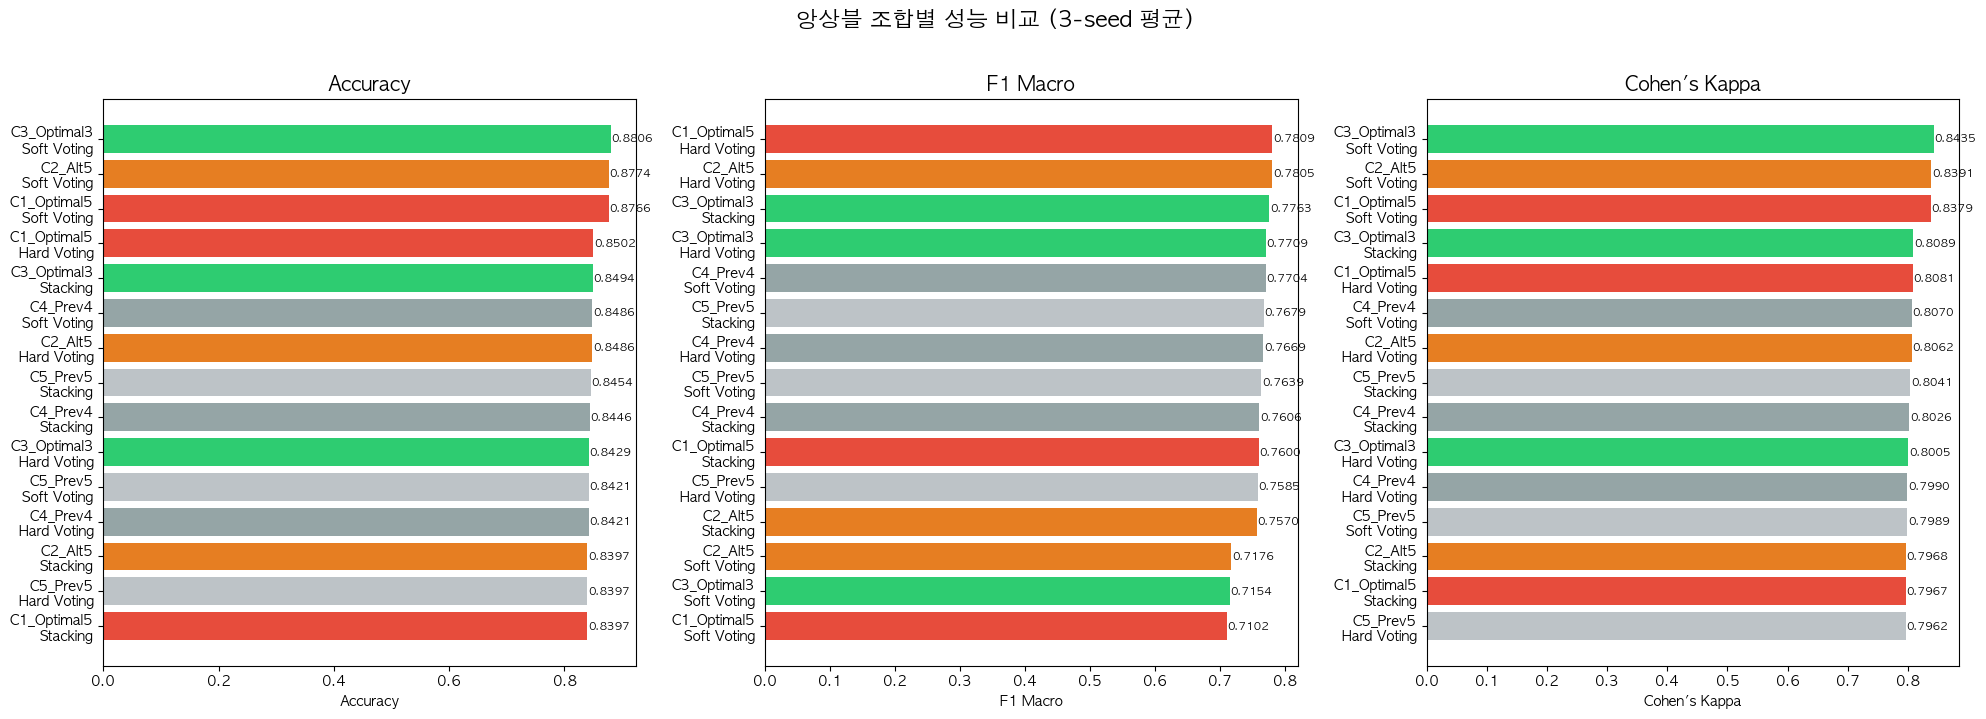

In [24]:
# 성능 비교 막대 그래프
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, metric in enumerate(['Acc_Mean', 'F1_Mean', 'Kappa_Mean']):
    ax = axes[idx]
    plot_data = summary.copy()
    plot_data['Label'] = plot_data['Combo'] + '\n' + plot_data['Method']
    plot_data = plot_data.sort_values(metric, ascending=True)

    colors = []
    for _, row in plot_data.iterrows():
        if 'Optimal5' in row['Combo']:
            colors.append('#e74c3c')
        elif 'Alt5' in row['Combo']:
            colors.append('#e67e22')
        elif 'Optimal3' in row['Combo']:
            colors.append('#2ecc71')
        elif 'Prev4' in row['Combo']:
            colors.append('#95a5a6')
        else:
            colors.append('#bdc3c7')

    ax.barh(plot_data['Label'], plot_data[metric], color=colors)

    title_map = {'Acc_Mean': 'Accuracy', 'F1_Mean': 'F1 Macro', 'Kappa_Mean': "Cohen's Kappa"}
    ax.set_title(title_map[metric], fontsize=14)
    ax.set_xlabel(title_map[metric])

    # 값 표시
    for i, (_, row) in enumerate(plot_data.iterrows()):
        ax.text(row[metric] + 0.001, i, f"{row[metric]:.4f}", va='center', fontsize=8)

plt.suptitle('앙상블 조합별 성능 비교 (3-seed 평균)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/summary/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**결과 해석:** 빨간색은 C1(최적 5개), 주황색은 C2(차선 5개), 초록색은 C3(최적 3개), 회색은 기존 조합입니다.
색상별로 Condorcet 기반 최적 조합이 기존 조합보다 우수한지 확인할 수 있습니다.

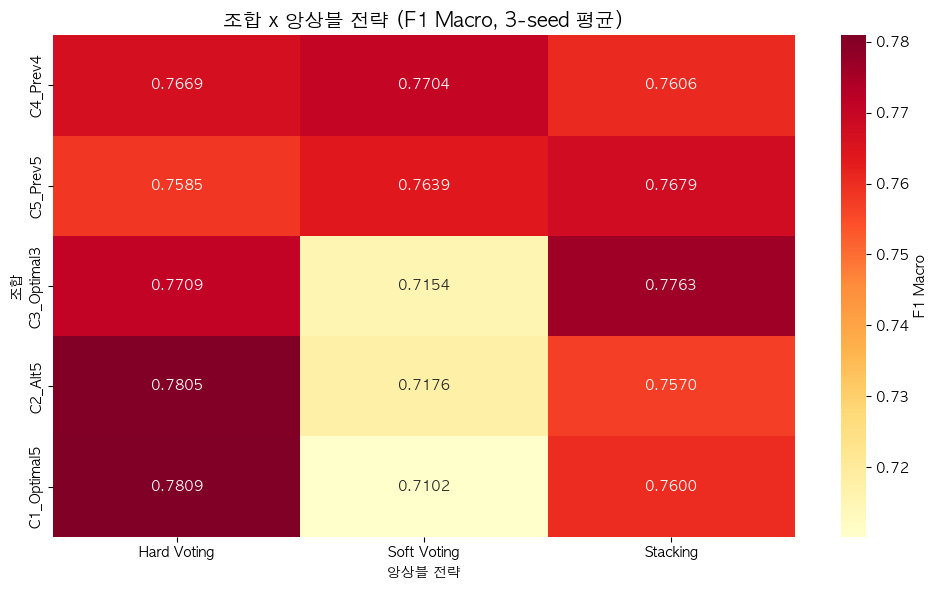

In [25]:
# 조합별 히트맵 (F1 Macro)
pivot = summary.pivot_table(
    index='Combo', columns='Method', values='F1_Mean'
)
# 평균 F1 기준 정렬
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=ax, cbar_kws={'label': 'F1 Macro'})
ax.set_title('조합 x 앙상블 전략 (F1 Macro, 3-seed 평균)', fontsize=14)
ax.set_xlabel('앙상블 전략')
ax.set_ylabel('조합')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/summary/heatmap_f1.png', dpi=150, bbox_inches='tight')
plt.show()

**결과 해석:** 히트맵에서 색이 진할수록 높은 F1 성능을 나타냅니다.
행(조합)과 열(전략)의 교차점에서 최적의 조합-전략 쌍을 식별할 수 있습니다.

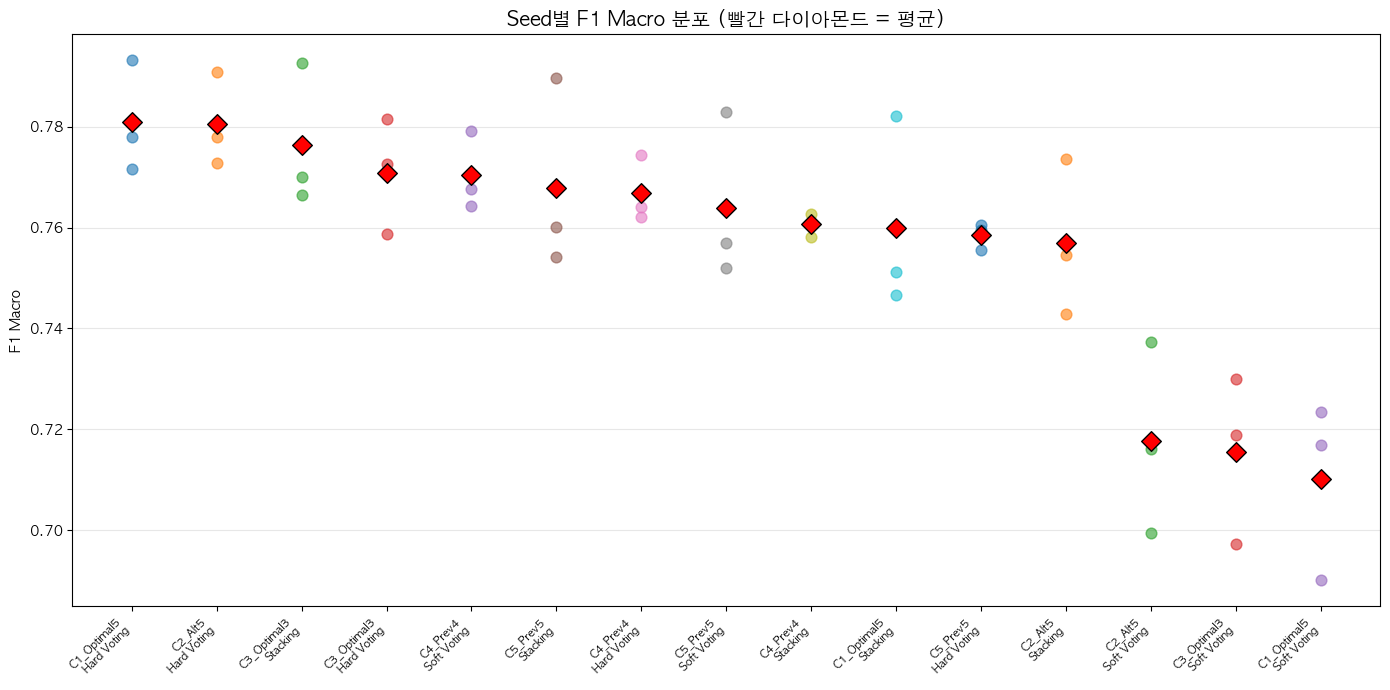

In [26]:
# Seed별 성능 안정성 비교
fig, ax = plt.subplots(figsize=(14, 7))

# 각 조합+방법별로 3개 seed의 F1 값을 점으로 표시
combo_method_labels = []
for _, row in summary.iterrows():
    label = f"{row['Combo']}\n{row['Method']}"
    combo_method_labels.append(label)

    subset = test_df_results[
        (test_df_results['Combo'] == row['Combo']) &
        (test_df_results['Method'] == row['Method'])
    ]
    x_pos = len(combo_method_labels) - 1
    ax.scatter([x_pos] * len(subset), subset['F1_Macro'],
              alpha=0.6, s=60, zorder=3)
    ax.scatter(x_pos, row['F1_Mean'], marker='D', s=100,
              color='red', zorder=4, edgecolors='black')

ax.set_xticks(range(len(combo_method_labels)))
ax.set_xticklabels(combo_method_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('F1 Macro')
ax.set_title('Seed별 F1 Macro 분포 (빨간 다이아몬드 = 평균)', fontsize=14)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/summary/seed_stability.png', dpi=150, bbox_inches='tight')
plt.show()

**결과 해석:** 파란 점은 개별 seed의 F1 값, 빨간 다이아몬드는 3-seed 평균입니다.
점들이 밀집되어 있을수록 seed에 관계없이 안정적인 성능을 보여줍니다.

**결과 해석:** 3개 seed 평균 성능에서 **F1 Macro** 기준으로 조합을 비교합니다.
F1 Macro는 모든 클래스에 동일한 가중치를 부여하므로 불균형 데이터에서 공정한 비교가 가능합니다.

> **주의**: Soft Voting은 Accuracy/Kappa가 높지만 F1 Macro가 낮을 수 있습니다. 이는 다수 클래스에 편향된 예측을 하기 때문입니다.

---
## 11. 학생별 예측 불일치 분석

### 예측 불일치 분석
최고 성능 앙상블 조합에 대해:
1. **혼동 행렬(Confusion Matrix)**: 각 seed에서 실제 레이블과 예측 레이블의 분포
2. **개별 모델 간 불일치**: 앙상블의 base learner들이 서로 다르게 예측한 비율
3. **앙상블의 오류 보정 효과**: 개별 모델이 불일치할 때 앙상블이 올바르게 예측한 비율

최고 조합: C1_Optimal5 + Hard Voting
컬럼명: C1_Optimal5_HardVoting


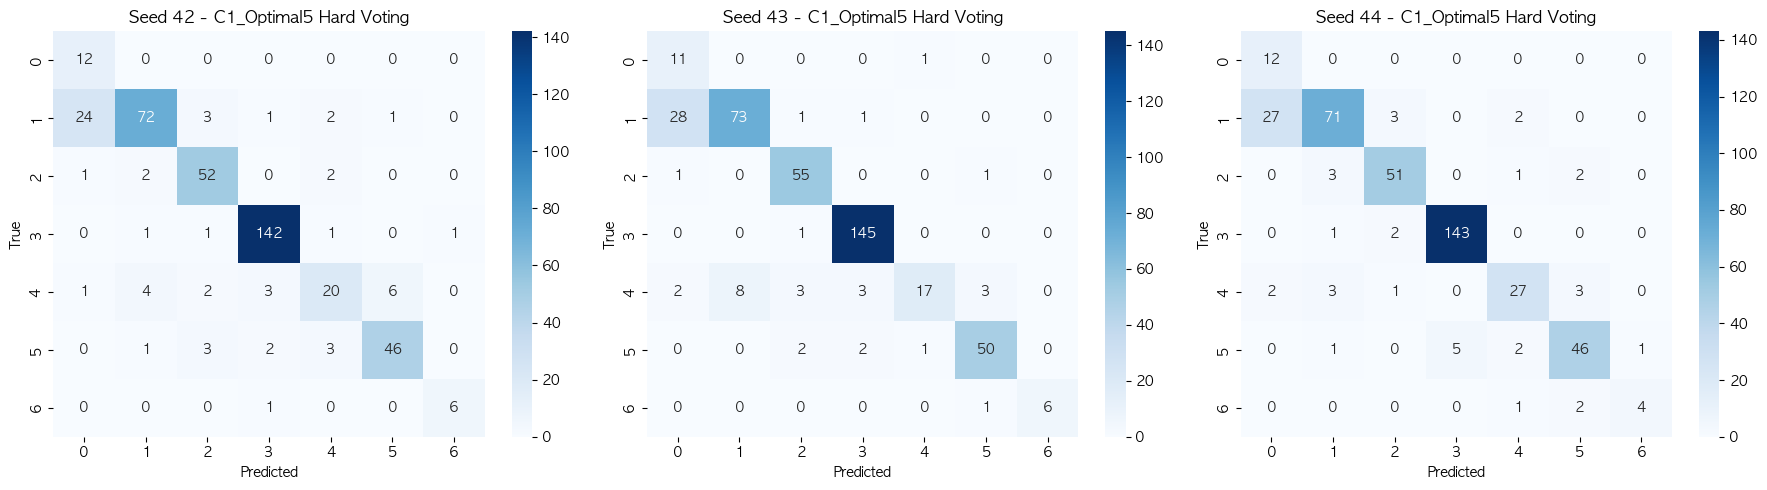

In [27]:
# 최고 조합에 대한 Confusion Matrix
best_combo = summary.iloc[0]['Combo']
best_method = summary.iloc[0]['Method']
best_col = f"{best_combo}_{best_method.replace(' ', '')}"

print(f"최고 조합: {best_combo} + {best_method}")
print(f"컬럼명: {best_col}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, pred_df in enumerate(all_prediction_dfs):
    seed = pred_df['seed'].iloc[0]
    if best_col not in pred_df.columns:
        print(f"  Seed {seed}: 컬럼 '{best_col}' 없음")
        continue

    y_true = pred_df['true_label']
    y_pred = pred_df[best_col]

    cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    axes[idx].set_title(f'Seed {seed} - {best_combo} {best_method}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/summary/confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# 개별 모델 간 예측 불일치 분석 (최고 조합의 base learners)
best_models = ENSEMBLE_COMBOS[best_combo]
print(f"최고 조합 base learners: {best_models}")

for pred_df in all_prediction_dfs:
    seed = pred_df['seed'].iloc[0]
    print(f"\n[Seed {seed}]")

    pred_cols = [f'{m}_pred' for m in best_models]
    model_preds = pred_df[pred_cols]

    # 전체 일치율
    all_agree = model_preds.nunique(axis=1) == 1
    print(f"  전체 일치: {all_agree.sum()}/{len(all_agree)} ({all_agree.mean()*100:.1f}%)")
    print(f"  불일치: {(~all_agree).sum()}/{len(all_agree)} ({(~all_agree).mean()*100:.1f}%)")

    # 불일치 샘플에서 최종 앙상블이 맞은 비율
    if best_col in pred_df.columns:
        disagree_idx = pred_df[~all_agree].index
        if len(disagree_idx) > 0:
            ensemble_correct = (pred_df.loc[disagree_idx, best_col] == pred_df.loc[disagree_idx, 'true_label']).mean()
            print(f"  불일치 샘플 앙상블 정확도: {ensemble_correct:.4f}")

최고 조합 base learners: ['SVM-L', 'CNB', 'DT', 'GB', 'XGB']

[Seed 42]
  전체 일치: 278/416 (66.8%)
  불일치: 138/416 (33.2%)
  불일치 샘플 앙상블 정확도: 0.5797

[Seed 43]
  전체 일치: 286/416 (68.8%)
  불일치: 130/416 (31.2%)
  불일치 샘플 앙상블 정확도: 0.5769

[Seed 44]
  전체 일치: 288/416 (69.2%)
  불일치: 128/416 (30.8%)
  불일치 샘플 앙상블 정확도: 0.5781


**결과 해석:** 개별 모델들이 약 30~33% 정도 불일치하며, 이 불일치 샘플에서 앙상블이 약 58%의 정확도를 보입니다.
이는 앙상블이 개별 모델의 오류를 부분적으로 보정하고 있음을 보여줍니다.

In [29]:
# 개별 모델 vs 앙상블 성능 비교 표
print("=" * 70)
print("최고 조합: 개별 모델 vs 앙상블 성능 비교")
print("=" * 70)

comparison_rows = []

for pred_df in all_prediction_dfs:
    seed = pred_df['seed'].iloc[0]
    y_true = pred_df['true_label']

    # 개별 모델
    for model_name in best_models:
        col = f'{model_name}_pred'
        if col in pred_df.columns:
            y_pred = pred_df[col]
            comparison_rows.append({
                'Seed': seed,
                'Type': 'Individual',
                'Name': model_name,
                'Accuracy': accuracy_score(y_true, y_pred),
                'F1_Macro': f1_score(y_true, y_pred, average='macro'),
                'Kappa': cohen_kappa_score(y_true, y_pred),
            })

    # 앙상블 방법들
    for method in ENSEMBLE_METHODS:
        col = f"{best_combo}_{method.replace(' ', '')}"
        if col in pred_df.columns:
            y_pred = pred_df[col]
            comparison_rows.append({
                'Seed': seed,
                'Type': 'Ensemble',
                'Name': method,
                'Accuracy': accuracy_score(y_true, y_pred),
                'F1_Macro': f1_score(y_true, y_pred, average='macro'),
                'Kappa': cohen_kappa_score(y_true, y_pred),
            })

comp_df = pd.DataFrame(comparison_rows)
comp_summary = comp_df.groupby(['Type', 'Name']).agg({
    'Accuracy': 'mean',
    'F1_Macro': 'mean',
    'Kappa': 'mean',
}).round(4).sort_values('F1_Macro', ascending=False)

print(comp_summary.to_string())

최고 조합: 개별 모델 vs 앙상블 성능 비교
                        Accuracy  F1_Macro   Kappa
Type       Name                                   
Ensemble   Hard Voting    0.8502    0.7809  0.8081
           Stacking       0.8397    0.7600  0.7967
Individual SVM-L          0.8413    0.7583  0.7977
Ensemble   Soft Voting    0.8766    0.7102  0.8379
Individual DT             0.8045    0.7069  0.7513
           XGB            0.8718    0.7040  0.8311
           CNB            0.7829    0.6803  0.7219
           GB             0.8558    0.6663  0.8090


**결과 해석:** Hard Voting 앙상블이 개별 모델(SVM-L 등) 대비 F1 Macro에서 개선을 보이는지 확인합니다.
앙상블의 가치는 개별 최고 모델보다 일관성 있게 높은 성능을 달성하는 데 있습니다.

---
## 12. 실험 설정 저장 및 종합 요약

In [30]:
# 실험 설정 저장
experiment_config = {
    'Date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Experiment': 'Optimal Ensemble Search (Condorcet-based)',
    'Seeds': SEEDS,
    'Vectorization': 'V1_Word',
    'CV_Folds': N_FOLDS,
    'CV_Method': 'Stratified K-Fold',
    'Ensemble_Combinations': {
        name: models for name, models in ENSEMBLE_COMBOS.items()
    },
    'Ensemble_Methods': ENSEMBLE_METHODS,
    'Total_Experiments': total_experiments,
    'Best_Result': {
        'Combo': str(best['Combo']),
        'Models': str(best['Models']),
        'Method': str(best['Method']),
        'N_Models': int(best['N_Models']),
        'Accuracy_Mean': float(best['Acc_Mean']),
        'F1_Macro_Mean': float(best['F1_Mean']),
        'Kappa_Mean': float(best['Kappa_Mean']),
    }
}

with open(f'{OUTPUT_DIR}/summary/experiment_config.json', 'w', encoding='utf-8') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)

print(f"실험 설정 저장: {OUTPUT_DIR}/summary/experiment_config.json")

실험 설정 저장: ./results/optimal_ensemble/summary/experiment_config.json


In [31]:
# 종합 요약
print("\n" + "=" * 70)
print("실험 완료 종합 요약")
print("=" * 70)

print(f"\n[최고 조합]")
print(f"  {best['Combo']}: {best['Models']}")
print(f"  전략: {best['Method']}")
print(f"  F1 Macro: {best['F1_Mean']:.4f} (±{best['F1_Std']:.4f})")
print(f"  Kappa:    {best['Kappa_Mean']:.4f} (±{best['Kappa_Std']:.4f})")

print(f"\n[저장 파일]")
print(f"  성능 요약:    {OUTPUT_DIR}/summary/combination_summary.csv")
print(f"  CV 결과:     {OUTPUT_DIR}/summary/cv_results.csv")
print(f"  Test 결과:   {OUTPUT_DIR}/summary/test_results.csv")
print(f"  실험 설정:    {OUTPUT_DIR}/summary/experiment_config.json")
print(f"  학생별 예측:  {OUTPUT_DIR}/predictions/student_predictions_all.xlsx")
for seed in SEEDS:
    print(f"               {OUTPUT_DIR}/predictions/student_predictions_seed{seed}.xlsx")

print(f"\n완료 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


실험 완료 종합 요약

[최고 조합]
  C1_Optimal5: SVM-L + CNB + DT + GB + XGB
  전략: Hard Voting
  F1 Macro: 0.7809 (±0.0111)
  Kappa:    0.8081 (±0.0107)

[저장 파일]
  성능 요약:    ./results/optimal_ensemble/summary/combination_summary.csv
  CV 결과:     ./results/optimal_ensemble/summary/cv_results.csv
  Test 결과:   ./results/optimal_ensemble/summary/test_results.csv
  실험 설정:    ./results/optimal_ensemble/summary/experiment_config.json
  학생별 예측:  ./results/optimal_ensemble/predictions/student_predictions_all.xlsx
               ./results/optimal_ensemble/predictions/student_predictions_seed42.xlsx
               ./results/optimal_ensemble/predictions/student_predictions_seed43.xlsx
               ./results/optimal_ensemble/predictions/student_predictions_seed44.xlsx

완료 시간: 2026-02-11 14:52:43
